In [2]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

from data_utils import load_data, add_bias_column
from train import train, run_multiple_seeds

In [3]:
train_in, train_out, test_in, test_out = load_data(data_dir="../data")

T_train = add_bias_column(train_in)
T_test = add_bias_column(test_in)

print("Train inputs:", T_train.shape)
print("Test inputs: ", T_test.shape)

Train inputs: (1707, 257)
Test inputs:  (1000, 257)


In [4]:
model, history = train(T_train, train_out, T_test, test_out,
                       num_epochs=20, lr=0.1, init="small_random", seed=0)

Epoch  1/20 | train_acc=0.9291  test_acc=0.8500  train_error_rate=0.2021
Epoch  2/20 | train_acc=0.9397  test_acc=0.8590  train_error_rate=0.1037
Epoch  3/20 | train_acc=0.9156  test_acc=0.8430  train_error_rate=0.0633
Epoch  4/20 | train_acc=0.9537  test_acc=0.8520  train_error_rate=0.0715
Epoch  5/20 | train_acc=0.9543  test_acc=0.8650  train_error_rate=0.0527
Epoch  6/20 | train_acc=0.9637  test_acc=0.8640  train_error_rate=0.0393
Epoch  7/20 | train_acc=0.9197  test_acc=0.8120  train_error_rate=0.0422
Epoch  8/20 | train_acc=0.9578  test_acc=0.8600  train_error_rate=0.0381
Epoch  9/20 | train_acc=0.9842  test_acc=0.8740  train_error_rate=0.0381
Epoch 10/20 | train_acc=0.9900  test_acc=0.8680  train_error_rate=0.0269
Epoch 11/20 | train_acc=0.9842  test_acc=0.8670  train_error_rate=0.0193
Epoch 12/20 | train_acc=0.9813  test_acc=0.8710  train_error_rate=0.0141
Epoch 13/20 | train_acc=0.9748  test_acc=0.8670  train_error_rate=0.0170
Epoch 14/20 | train_acc=0.9742  test_acc=0.8660  tr

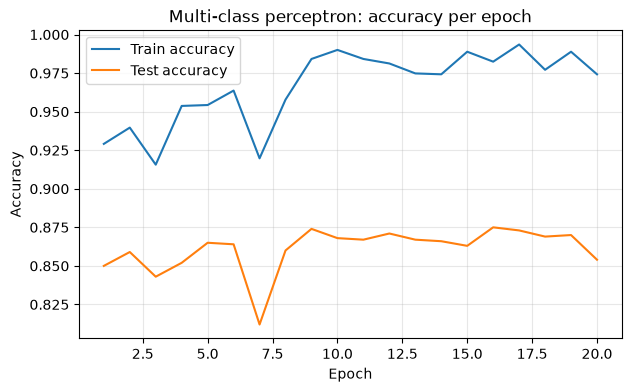

In [6]:
epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_acc"], label="Train accuracy")
plt.plot(epochs, history["test_acc"], label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Multi-class perceptron: accuracy per epoch")
plt.legend()
plt.grid(alpha=0.3)
import os
os.makedirs("../results/plots", exist_ok=True)
plt.savefig("../results/plots/accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
seeds = list(range(10))
results = run_multiple_seeds(T_train, train_out, T_test, test_out, seeds,
                              num_epochs=20, lr=0.1, init="small_random")

final_test_accs = [r["final_test_acc"] for r in results]
print(f"Test accuracy over {len(seeds)} seeds: "
      f"mean={np.mean(final_test_accs):.4f}, std={np.std(final_test_accs):.4f}")

Epoch  1/20 | train_acc=0.9291  test_acc=0.8500  train_error_rate=0.2021
Epoch  2/20 | train_acc=0.9397  test_acc=0.8590  train_error_rate=0.1037
Epoch  3/20 | train_acc=0.9156  test_acc=0.8430  train_error_rate=0.0633
Epoch  4/20 | train_acc=0.9537  test_acc=0.8520  train_error_rate=0.0715
Epoch  5/20 | train_acc=0.9543  test_acc=0.8650  train_error_rate=0.0527
Epoch  6/20 | train_acc=0.9637  test_acc=0.8640  train_error_rate=0.0393
Epoch  7/20 | train_acc=0.9197  test_acc=0.8120  train_error_rate=0.0422
Epoch  8/20 | train_acc=0.9578  test_acc=0.8600  train_error_rate=0.0381
Epoch  9/20 | train_acc=0.9842  test_acc=0.8740  train_error_rate=0.0381
Epoch 10/20 | train_acc=0.9900  test_acc=0.8680  train_error_rate=0.0269
Epoch 11/20 | train_acc=0.9842  test_acc=0.8670  train_error_rate=0.0193
Epoch 12/20 | train_acc=0.9813  test_acc=0.8710  train_error_rate=0.0141
Epoch 13/20 | train_acc=0.9748  test_acc=0.8670  train_error_rate=0.0170
Epoch 14/20 | train_acc=0.9742  test_acc=0.8660  tr

In [8]:
for init in ["zeros", "small_random", "large_random"]:
    _, h = train(T_train, train_out, T_test, test_out,
                 num_epochs=20, lr=0.1, init=init, seed=0)
    print(f"init={init:>12s} -> final test acc = {h['test_acc'][-1]:.4f}\n")

Epoch  1/20 | train_acc=0.8828  test_acc=0.8320  train_error_rate=0.1921
Epoch  2/20 | train_acc=0.8910  test_acc=0.8080  train_error_rate=0.1090
Epoch  3/20 | train_acc=0.9520  test_acc=0.8720  train_error_rate=0.0744
Epoch  4/20 | train_acc=0.9590  test_acc=0.8660  train_error_rate=0.0697
Epoch  5/20 | train_acc=0.9660  test_acc=0.8620  train_error_rate=0.0521
Epoch  6/20 | train_acc=0.9584  test_acc=0.8480  train_error_rate=0.0504
Epoch  7/20 | train_acc=0.9684  test_acc=0.8570  train_error_rate=0.0381
Epoch  8/20 | train_acc=0.9789  test_acc=0.8710  train_error_rate=0.0422
Epoch  9/20 | train_acc=0.9783  test_acc=0.8620  train_error_rate=0.0357
Epoch 10/20 | train_acc=0.9941  test_acc=0.8760  train_error_rate=0.0199
Epoch 11/20 | train_acc=0.9818  test_acc=0.8590  train_error_rate=0.0182
Epoch 12/20 | train_acc=0.9783  test_acc=0.8740  train_error_rate=0.0217
Epoch 13/20 | train_acc=0.9772  test_acc=0.8620  train_error_rate=0.0164
Epoch 14/20 | train_acc=0.9807  test_acc=0.8660  tr

Epoch  1/20 | train_acc=0.9238  test_acc=0.8480  train_error_rate=0.2097
Epoch  2/20 | train_acc=0.9180  test_acc=0.8050  train_error_rate=0.0967
Epoch  3/20 | train_acc=0.9490  test_acc=0.8620  train_error_rate=0.0627
Epoch  4/20 | train_acc=0.9520  test_acc=0.8460  train_error_rate=0.0633
Epoch  5/20 | train_acc=0.9561  test_acc=0.8570  train_error_rate=0.0510
Epoch  6/20 | train_acc=0.9315  test_acc=0.8260  train_error_rate=0.0439
Epoch  7/20 | train_acc=0.9596  test_acc=0.8570  train_error_rate=0.0416
Epoch  8/20 | train_acc=0.9748  test_acc=0.8700  train_error_rate=0.0340
Epoch  9/20 | train_acc=0.9836  test_acc=0.8730  train_error_rate=0.0351
Epoch 10/20 | train_acc=0.9836  test_acc=0.8630  train_error_rate=0.0205
Epoch 11/20 | train_acc=0.9795  test_acc=0.8640  train_error_rate=0.0170
Epoch 12/20 | train_acc=0.9865  test_acc=0.8720  train_error_rate=0.0264
Epoch 13/20 | train_acc=0.9930  test_acc=0.8700  train_error_rate=0.0164
Epoch 14/20 | train_acc=0.9719  test_acc=0.8530  tr

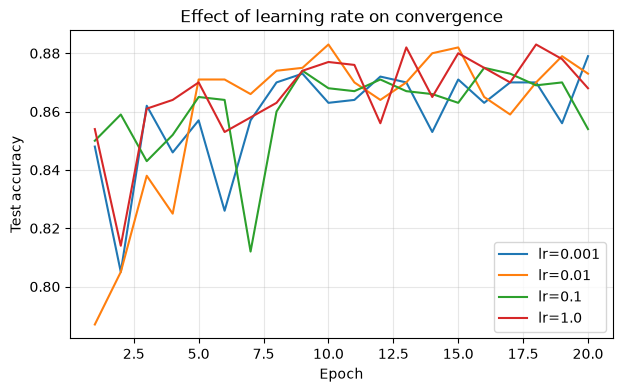

In [9]:
plt.figure(figsize=(7, 4))
for lr in [0.001, 0.01, 0.1, 1.0]:
    _, h = train(T_train, train_out, T_test, test_out,
                 num_epochs=20, lr=lr, init="small_random", seed=0)
    plt.plot(range(1, 21), h["test_acc"], label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.title("Effect of learning rate on convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("../results/plots/lr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()